# MA Transmuting LFR model

#### Remarks on version 2_4_ALR:
Building on BLiu_model_2_1

Materials updated (code made clean, and correct variables used now)

Implementing temperatures found in C.Seng (From Amalia):  
NB1: Temperature for helium just set to av of T_fuel_av and T_fuel_cool (estimated non-important, due to low neutron abs. of helium)  
NB2: Temp for blanket is set to T_cool_av, as fission events (heat sources) in blanket are deemed insignificant (Tab 7 i B.Liu)  
NB3: Temp for control rods set to T_cool_av (but deemed non-important, as we model with no control rods...)

Using library: ENDFB-VII.1

Implementing tallies from Filips BLiu_model_2_2 to produce flux spectrae

#### From Bin Liu et al., "Minor actinide transmutation in the lead-cooled fast reactor", 2020

In [1]:
%matplotlib inline
import openmc
import math

import os 
#os.environ['OPENMC_CROSS_SECTIONS']='openmc_venv/root/endf-b-vii.1/'
os.environ['OPENMC_CROSS_SECTIONS']='/openmc_data/endfb-viii.1-hdf5/cross_sections.xml'
print('done')

done


## General params

In [2]:
#From C. Seng (2019), table 3, "average"
#converted to K
T_fuel_in= 1175.17 + 273.15  #converted to K
T_fuel_out = 1318.55 + 273.15
T_fuel_av = (T_fuel_in + T_fuel_out)/2

#Cladding temp as average between inner and outer (mid) to ease implementation
T_clad_in = 502.38 + 273.15
T_clad_out = 496.04 + 273.15
T_clad_av = (T_clad_in + T_clad_out)/2 

#Coolant temp as average between inner and outer (mid) to ease implementation
T_cool_in = 479.21 + 273.15
T_cool_out = 480.87 + 273.15
T_cool_av = (T_cool_in + T_cool_out)/2 

######## INSERT HERE: ###########
#Percentage of MA mixed in fuel
percent_MA_in_fuel_hom = 0 #from 0 to 1
#################################


## Materials
Using actual materials compositions from article

### Isotopes and materials

In [3]:
### For fuel oxides
# Natural composition of O
o_nat = openmc.Material(name='O natural')
o_nat.add_element('O', 1.0)
o_nat.set_density('g/cm3', 1.4) # This is for gas-form from wiki. Will be overwritten when used in mixture

### Misc.
sodium = openmc.Material(name='Na')
sodium.add_nuclide('Na23', 1.0)
sodium.set_density('g/cm3', 0.9688) #wiki 

Pb = openmc.Material(name='Pb')
Pb.add_element('Pb', 1.0)
Pb.set_density('g/cm3', 11.348) #wiki

### For MA mixes:

Np237 = openmc.Material(name='Np237')
Np237.add_nuclide('Np237', 1.0)
Np237.set_density('g/cm3', 20.45) #wiki

Am241 = openmc.Material(name='Am241')
Am241.add_nuclide('Am241', 1.0)
Am241.set_density('g/cm3', 12) #wiki

Am243 = openmc.Material(name='Am243')
Am243.add_nuclide('Am243', 1.0)
Am241.set_density('g/cm3', 12) #wiki

Cm244 = openmc.Material(name='Cm244')
Cm244.add_nuclide('Cm244', 1.0)
Cm244.set_density('g/cm3', 13.51) #wiki

Cm245 = openmc.Material(name='Cm245')
Cm245.add_nuclide('Cm245', 1.0) 
Cm245.set_density('g/cm3', 13.51) #wiki

# For control rods

B_enriched = openmc.Material(name='B_enriched')
B_enriched.add_nuclide('B10', 0.92)
B_enriched.add_nuclide('B11', 0.08)


### For T91

# Carbon
C = openmc.Material(name='C')
C.set_density('g/cm3', 2.266)
#Use 'C0' when using ENDFB-VII.1
C.add_nuclide('C12', 1)
#C.add_nuclide('C0', 1)

# Nitrogen
N = openmc.Material(name='N')
N.set_density('g/cm3', 1.165e-3)  # gas at STP
N.add_element('N', 1)

# Aluminum
Al = openmc.Material(name='Al')
Al.set_density('g/cm3', 2.70)
Al.add_element('Al', 1)

# Silicon
Si = openmc.Material(name='Si')
Si.set_density('g/cm3', 2.33)
Si.add_element('Si', 1)

# Phosphorus
P = openmc.Material(name='P')
P.set_density('g/cm3', 1.82)
P.add_element('P', 1)

# Sulfur
S = openmc.Material(name='S')
S.set_density('g/cm3', 2.07)
S.add_element('S', 1)

# Vanadium
V = openmc.Material(name='V')
V.set_density('g/cm3', 6.11)
V.add_element('V', 1)

# Chromium
Cr = openmc.Material(name='Cr')
Cr.set_density('g/cm3', 7.19)
Cr.add_element('Cr', 1)

# Manganese
Mn = openmc.Material(name='Mn')
Mn.set_density('g/cm3', 7.21)
Mn.add_element('Mn', 1)

# Iron
Fe = openmc.Material(name='Fe')
Fe.set_density('g/cm3', 7.87)
Fe.add_element('Fe', 1)

# Nickel
Ni = openmc.Material(name='Ni')
Ni.set_density('g/cm3', 8.90)
Ni.add_element('Ni', 1)

# Copper
Cu = openmc.Material(name='Cu')
Cu.set_density('g/cm3', 8.96)
Cu.add_element('Cu', 1)

# Niobium
Nb = openmc.Material(name='Nb')
Nb.set_density('g/cm3', 8.57)
Nb.add_element('Nb', 1)

# Molybdenum
Mo = openmc.Material(name='Mo')
Mo.set_density('g/cm3', 10.28)
Mo.add_element('Mo', 1)

# Helium
He = openmc.Material(name='He')
He.set_density('g/cm3', 0.0001785)
He.add_element('He', 1)

### U and Pu vectors for fuel elements

In [4]:
#Uranium vector for fuel (from B.Liu Table 4)
u_fuel = openmc.Material(name="UraniumVector")
u_fuel.add_nuclide("U234", 0.00003, percent_type="wo")
u_fuel.add_nuclide("U235", 0.00404, percent_type="wo")
u_fuel.add_nuclide("U236", 0.00010, percent_type="wo")
u_fuel.add_nuclide("U238", 0.99583, percent_type="wo")
u_fuel.set_density('g/cm3', 19.1) #Density dervied from wiki

#Uranium vector for blanket (from B.Liu Table 2)
u_blanket = openmc.Material(name="UraniumVector")
u_blanket.add_nuclide("U235", 0.0072, percent_type="wo")
u_blanket.add_nuclide("U238", 0.9928, percent_type="wo")
u_blanket.set_density('g/cm3', 19.1) #Set same as uranium vector in fuel

#Plutonium vector for fuel (from B.Liu Table 4)
pu_fuel = openmc.Material(name="PlutoniumVector")
pu_fuel.add_nuclide("Pu238", 0.02332, percent_type="wo")
pu_fuel.add_nuclide("Pu239", 0.56873, percent_type="wo")
pu_fuel.add_nuclide("Pu240", 0.26997, percent_type="wo")
pu_fuel.add_nuclide("Pu241", 0.06105, percent_type="wo")
pu_fuel.add_nuclide("Pu242", 0.07693, percent_type="wo")
pu_fuel.set_density("g/cm3", 19.8)

### Uranium and Plutonium oxides

In [5]:
########## Uranium and Plutonium Oxides: ########
#################################################
# UO2, Blanket 
uo2_blanket = openmc.Material.mix_materials(
    [u_blanket, o_nat],
    [2/3,1/3],
    percent_type='ao',
    name='Blanket UO2'
)
uo2_blanket.set_density('g/cm3', 10.97) # from wiki, temp not specified...

# UO2, fuel
uo2_fuel = openmc.Material.mix_materials(
    [u_fuel, o_nat],
    [2/3,1/3],
    percent_type='ao',
    name='Fuel UO2'
)
uo2_fuel.set_density('g/cm3', 10.97) # from wiki, temp not specified...

# PuO2, fuel
puo2_fuel = openmc.Material.mix_materials(
    [pu_fuel, o_nat],
    [2/3,1/3],
    percent_type='ao',
    name='Fuel PuO2'
)
uo2_fuel.set_density('g/cm3', 11.5) # from wiki, temp not specified...

### Percentage of MAs in fuel implemented

In [6]:
# U- and Pu-content in fuel (in=inner, mid=middle, out=outmost)
U_in_fuel = 0.862*(1-percent_MA_in_fuel_hom)
Pu_in_fuel = 0.138*(1-percent_MA_in_fuel_hom)

U_mid_fuel = 0.835*(1-percent_MA_in_fuel_hom)
Pu_mid_fuel = 0.165*(1-percent_MA_in_fuel_hom)

U_out_fuel = 0.788*(1-percent_MA_in_fuel_hom)
Pu_out_fuel = 0.212*(1-percent_MA_in_fuel_hom)

#Verifying U, Pu and MA content in fuel:
print("Content of U, Pu, when MAs in fuel:")
print("U_in_fuel", U_in_fuel)
print("Pu_in_fuel", Pu_in_fuel)
print("MA_in_fuel", percent_MA_in_fuel_hom)

print("U_mid_fuel", U_mid_fuel)
print("Pu_mid_fuel", Pu_mid_fuel)
print("MA_mid_fuel", percent_MA_in_fuel_hom)

print("U_out_fuel", U_out_fuel)
print("Pu_out_fuel", Pu_out_fuel)
print("MA_out_fuel", percent_MA_in_fuel_hom)

Content of U, Pu, when MAs in fuel:
U_in_fuel 0.862
Pu_in_fuel 0.138
MA_in_fuel 0
U_mid_fuel 0.835
Pu_mid_fuel 0.165
MA_mid_fuel 0
U_out_fuel 0.788
Pu_out_fuel 0.212
MA_out_fuel 0


### MA mix and fuel with MA mixed in

In [7]:
# Minor Actinide mix:
MA_mix = openmc.Material.mix_materials(
    [Np237, Am241, Am243, Cm244, Cm245],
    [0.5618, 0.264, 0.12, 0.0514, 0.0028],
    percent_type='wo',
    name = "Minor Actinide Mixture"
)


# internal fuel material
mat_in_fuel = openmc.Material.mix_materials(
    [uo2_fuel, puo2_fuel, MA_mix],
    [U_in_fuel, Pu_in_fuel, percent_MA_in_fuel_hom],
    percent_type='wo',
    name = 'internal fuel',
    temperature = T_fuel_in
)

# middle (intermediate) fuel material
mat_mid_fuel = openmc.Material.mix_materials(
    [uo2_fuel, puo2_fuel, MA_mix],
    [U_mid_fuel, Pu_mid_fuel, percent_MA_in_fuel_hom],
    percent_type='wo',
    name = 'middle fuel',
    temperature = T_fuel_av
)

# outmost fuel material
mat_out_fuel = openmc.Material.mix_materials(
    [uo2_fuel, puo2_fuel, MA_mix],
    [U_out_fuel, Pu_out_fuel , percent_MA_in_fuel_hom],
    percent_type='wo',
    name = 'outmost fuel',
    temperature = T_fuel_out
)


### Non-fuel materials

In [8]:
# clad material
mat_clad = openmc.Material.mix_materials(
    [C, N, Al, Si, P, S, V, Cr, Mn, Fe, Ni, Cu, Nb, Mo],
    [0.001, 0.00048, 0.00022, 0.0028, 0.00009, 0.00003, 0.00216, 0.0837, 0.0045, 0.89146, 0.0021, 0.0017, 0.00076, 0.009], 
    percent_type ='wo',
    name = 'clad',
    temperature = T_clad_av
    )
mat_clad.set_density('g/cm3', 7.77) #Density from www.metalspiping.com/t91-p91-steel.html

# helium gap material
mat_gap = openmc.Material.mix_materials(
    [He], 
    [1], 
    percent_type = 'ao',
    name = 'helium gap',
    temperature = (T_fuel_av + T_cool_av)/2
)

# blanket material
mat_blan = openmc.Material.mix_materials(
    [uo2_blanket], 
    [1], 
    percent_type = 'ao',
    name = 'blanket',
    temperature = T_cool_av
)

# control rod material
mat_cont = openmc.Material.mix_materials(
    [B_enriched, C],
    [0.8, 0.2],
    percent_type = 'ao',   # atomic fractions
    name = 'control rod',
    temperature = T_cool_av
)
mat_cont.set_density('g/cm3', 2.52)

# coolant (lead) material
mat_cool = openmc.Material.mix_materials(
    [Pb],
    [1.0],
    percent_type='ao',   # atomic fractions
    name = 'control rod',
    temperature = T_cool_av
)

In [9]:
# Instantiate a Materials collection and export to xml
materials_file = openmc.Materials([
    mat_in_fuel, 
    mat_mid_fuel,
    mat_out_fuel,
    mat_clad,
    mat_gap,
    mat_blan,
    mat_cont,
    mat_cool])

materials_file.export_to_xml() 

## Geometry

### Regions

In [10]:
# Size parameters (NB: OpenMC uses cm)
diam_fuel_pellet = 9.1e-1 #diameter of fuel pellet
thick_clad = 0.4e-1 #thickness of clad
out_diam_clad = 10.4e-1 #outer diameter of clad
in_diam_clad = out_diam_clad - thick_clad*2 #inner diameter of clad
height_core = 110 #active core height

# Surfaces
surf_fuel_or = openmc.ZCylinder(r=diam_fuel_pellet/2, name='fuel pellet') 
surf_clad_ir = openmc.ZCylinder(r=in_diam_clad/2, name='clad inner radius')
surf_clad_or = openmc.ZCylinder(r=out_diam_clad/2, name='clad outer radius')

surf_top = openmc.ZPlane(z0=height_core/2, boundary_type='vacuum', name='top')
surf_bot = openmc.ZPlane(z0=-height_core/2, boundary_type='vacuum', name='bottom')

# Regions
reg_fuel = -surf_top & +surf_bot & -surf_fuel_or 
reg_gap = -surf_top & +surf_bot & +surf_fuel_or & -surf_clad_ir
reg_clad = -surf_top & +surf_bot & +surf_clad_ir & -surf_clad_or
reg_cool =  -surf_top & +surf_bot & + surf_clad_or

#control rod geometry not specified in B. Liu: assumed not cladding
reg_cont = -surf_top & +surf_bot & -surf_clad_or 

### Primitive cells

In [11]:
# Fuel
cell_in_fuel = openmc.Cell(fill=mat_in_fuel, region=reg_fuel, name='fuel, internal')
cell_mid_fuel = openmc.Cell(fill=mat_mid_fuel, region=reg_fuel, name='fuel, middle')
cell_out_fuel = openmc.Cell(fill=mat_out_fuel, region=reg_fuel, name='fuel, outmost')

#(Defining multiple similar cells, in order for universes to avoid using same cells)
# Gap
cell_in_gap = openmc.Cell(fill=mat_gap, region=reg_gap, name='gap, internal')
cell_mid_gap = openmc.Cell(fill=mat_gap, region=reg_gap, name='gap, middle')
cell_out_gap = openmc.Cell(fill=mat_gap, region=reg_gap, name='gap, outmost')

# Clad
cell_in_clad = openmc.Cell(fill=mat_clad, region=reg_clad, name='clad, internal')
cell_mid_clad = openmc.Cell(fill=mat_clad, region=reg_clad, name='clad, middle')
cell_out_clad = openmc.Cell(fill=mat_clad, region=reg_clad, name='clad, outmost')

# Coolant
cell_in_cool = openmc.Cell(fill=mat_cool, region=reg_cool, name='coolant, internal')
cell_mid_cool = openmc.Cell(fill=mat_cool, region=reg_cool, name='coolant, middle')
cell_out_cool = openmc.Cell(fill=mat_cool, region=reg_cool, name='coolant, outmost')

# Coolant, but as filling for empty space in the core 
cell_empty_cool = openmc.Cell(fill=mat_cool, name='coolant, empty space in lattice') 

# Blanket
cell_blan = openmc.Cell(fill=mat_blan, region=reg_fuel, name='blanket')
cell_gap_blan = openmc.Cell(fill=mat_gap, region=reg_gap, name='gap in blanket ass.')
cell_clad_blan = openmc.Cell(fill=mat_clad, region=reg_clad, name='clad in blanket ass.')
cell_cool_blan = openmc.Cell(fill=mat_cool, region=reg_cool, name='coolant in blanket ass.')

# Control rod 
#control assemblies not specified in B. Liu: 
#assumed that not all rods in control assembly are control material, but that some are fuel material
#--> need for defining more similar cells to avoid dubilcation in universe creation
cell_in_cont = openmc.Cell(fill=mat_cont, region=reg_cont, name='control rod, internal')
cell_out_cont = openmc.Cell(fill=mat_cont, region=reg_cont, name='control rod, outmost')

cell_in_fuel_cont = openmc.Cell(fill=mat_in_fuel, region=reg_fuel, name='fuel in cont. ass., internal')
cell_out_fuel_cont = openmc.Cell(fill=mat_out_fuel, region=reg_fuel, name='fuel in cont. ass., outmost')

cell_in_gap_cont = openmc.Cell(fill=mat_gap, region=reg_gap, name='gap in cont. ass., internal')
cell_out_gap_cont = openmc.Cell(fill=mat_gap, region=reg_gap, name='gap in cont. ass., outmost')

cell_in_clad_cont = openmc.Cell(fill=mat_clad, region=reg_clad, name='clad in cont. ass., internal')
cell_out_clad_cont = openmc.Cell(fill=mat_clad, region=reg_clad, name='clad in cont. ass., outmost')

cell_in_cool_cont = openmc.Cell(fill=mat_cool, region=reg_cool, name='coolant in cont. ass., internal')
cell_out_cool_cont = openmc.Cell(fill=mat_cool, region=reg_cool, name='coolant in cont. ass., outmost')

# Assembly Cladding:
cell_in_as_clad = openmc.Cell(fill=mat_clad, region=reg_clad, name='clad, internal')
cell_mid_as_clad = openmc.Cell(fill=mat_clad, region=reg_clad, name='clad, middle')
cell_out_as_clad = openmc.Cell(fill=mat_clad, region=reg_clad, name='clad, outmost')
# 

### Primitive universes

In [12]:
# For fuel assemblies (internal, middle, outmost)
uni_in_fuel = openmc.Universe(
    cells=(cell_in_fuel, cell_in_gap, cell_in_clad, cell_in_cool),
    name='fuel assembly, internal'
    )
uni_mid_fuel = openmc.Universe(
    cells=(cell_mid_fuel, cell_mid_gap, cell_mid_clad, cell_mid_cool),
    name='fuel assembly, middle'
    )
uni_out_fuel = openmc.Universe(
    cells=(cell_out_fuel, cell_out_gap, cell_out_clad, cell_out_cool),
    name='fuel assembly, outmost'
    )

# For blanket assemblies
uni_blan = openmc.Universe(
    cells=(cell_blan, cell_gap_blan, cell_clad_blan, cell_cool_blan),
    name='blanket assembly'
    )

# For coolant in empty space in core
uni_empty_cool = openmc.Universe(cells=(cell_empty_cool,), name='coolant, empty space in lattice')

# For control assemblies
uni_in_cont = openmc.Universe(
    cells=(cell_in_cont, cell_in_fuel_cont, cell_in_gap_cont, cell_in_clad_cont, cell_in_cool_cont),
    name='control assembly, internal'
    )
uni_out_cont = openmc.Universe(
    cells=(cell_out_cont, cell_out_fuel_cont, cell_out_gap_cont, cell_out_clad_cont, cell_out_cool_cont),
    name='control assembly, outmost'
    )

In [13]:
# Plotting colors for cells

#...

<Axes: xlabel='x [cm]', ylabel='y [cm]'>

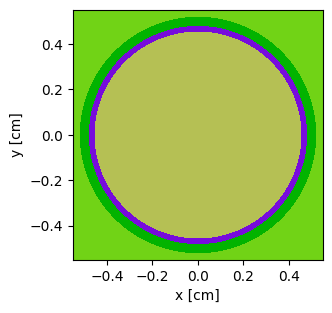

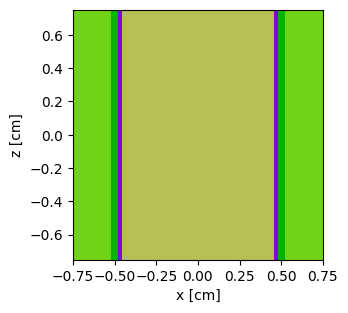

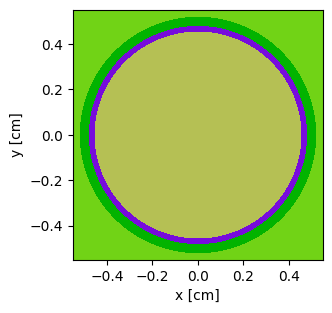

In [14]:
# Plotting
uni_in_fuel.plot(origin=(0.,0.,0.), pixels=(250, 250), width=(1.1,1.1), color_by='cell')
uni_in_fuel.plot(origin=(0.,0.,0.), pixels=(250, 250), width=(1.5,1.5), color_by='cell', basis='xz')
uni_blan.plot(origin=(0.,0.,0.), pixels=(250, 250), width=(1.1,1.1), color_by='cell')

### Lattice for internal fuel assemblies

In [15]:
# Size parameters for all lattices
pitch_fuel_rod = 13.6e-1 #fuel rod pitch

#Edge length of inner hexagonal for fuel assembly casing, (inner hexagonal, since casing has a thickness) 
edge_fuel_ass_in = 5.5*pitch_fuel_rod # factor before 'pitch_fuel_rod' is chosen at will...
print('Edge length of inner hexagonal: ', edge_fuel_ass_in)

#Thickness of outer hexagonal casing 
thick_ass_casing = 0.4

#Edge length of outer hexagonal casing 
#(NB: geometrix consideration needed, as dist. betw. same corner for inner and outer hex. not equal given thickness of casing)
edge_fuel_ass_out = edge_fuel_ass_in + 2/math.sqrt(3)*thick_ass_casing
print('Edge length of outer hexagonal: ', edge_fuel_ass_out)


Edge length of inner hexagonal:  7.48
Edge length of outer hexagonal:  7.941880215351701


In [16]:
# Defining lattice parameters
lat_in_fuel = openmc.HexLattice(name='internal fuel assembly')
lat_in_fuel.center = (0.,0.)
lat_in_fuel.pitch = (pitch_fuel_rod,)
lat_in_fuel.orientation = 'x'
lat_in_fuel.outer = uni_empty_cool

In [17]:
#Show layout of assemblies and indices
print(lat_in_fuel.show_indices(num_rings=6, orientation = 'x'))

                              (0,20)      (0,21)      (0,22)      (0,23)      (0,24)      (0,25)

                        (0,19)      (1,16)      (1,17)      (1,18)      (1,19)      (1,20)      (0,26)

                  (0,18)      (1,15)      (2,12)      (2,13)      (2,14)      (2,15)      (1,21)      (0,27)

            (0,17)      (1,14)      (2,11)      (3, 8)      (3, 9)      (3,10)      (2,16)      (1,22)      (0,28)

      (0,16)      (1,13)      (2,10)      (3, 7)      (4, 4)      (4, 5)      (3,11)      (2,17)      (1,23)      (0,29)

(0,15)      (1,12)      (2, 9)      (3, 6)      (4, 3)      (5, 0)      (4, 0)      (3, 0)      (2, 0)      (1, 0)      (0, 0)

      (0,14)      (1,11)      (2, 8)      (3, 5)      (4, 2)      (4, 1)      (3, 1)      (2, 1)      (1, 1)      (0, 1)

            (0,13)      (1,10)      (2, 7)      (3, 4)      (3, 3)      (3, 2)      (2, 2)      (1, 2)      (0, 2)

                  (0,12)      (1, 9)      (2, 6)      (2, 5)      (2, 4)      (2, 3)

In [18]:
# Creating 6 rings
infuel1 = [uni_in_fuel] * (6-1)*6 #=30
infuel2 = [uni_in_fuel] * (6-2)*6
infuel3 = [uni_in_fuel] * (6-3)*6 #...
infuel4 = [uni_in_fuel] * (6-4)*6 #=12
infuel5 = [uni_in_fuel] * (6-5)*6 #=6
infuel6 = [uni_in_fuel] * 1
lat_in_fuel.universes = [infuel1, infuel2, infuel3, infuel4, infuel5, infuel6]

# Create prisms that will define lattice and assembly cladding 
surf_inlat_in_fuel = openmc.model.HexagonalPrism(edge_length=edge_fuel_ass_in, orientation='x') #'inlat' = inner lattice
surf_outlat_in_fuel = openmc.model.HexagonalPrism(edge_length=edge_fuel_ass_out, orientation='x', boundary_type='transmission') #'outlat' = outer lattice

edge_fuel_ass_out_BC = edge_fuel_ass_out + 0.25


# Region
reg_main_lat_in_fuel = -surf_top & + surf_bot & -surf_inlat_in_fuel #inside inner hexagonal (for fuel rod lattice)
reg_clad_lat_in_fuel = -surf_top & + surf_bot & +surf_inlat_in_fuel & -surf_outlat_in_fuel #between two hex. surf. (for cladding)

reg_out_lat_in_fuel = -surf_top & + surf_bot & +surf_outlat_in_fuel #outside outer hexagonal (for coolant)

#Fill a cell with the lattice. This cell is filled with the lattice and contained within the prism
cell_main_lat_in_fuel = openmc.Cell(fill=lat_in_fuel, region=reg_main_lat_in_fuel)
#cladding:
cell_clad_lat_in_fuel = openmc.Cell(fill=mat_clad, region=reg_clad_lat_in_fuel)
#Fill a cell with a material that will surround the prism assembly

cell_out_lat_in_fuel = openmc.Cell(fill=mat_cool, region=reg_out_lat_in_fuel)



# Universe containing the cells
uni_main_in_fuel = openmc.Universe(
    cells=[cell_main_lat_in_fuel, cell_clad_lat_in_fuel, cell_out_lat_in_fuel], 
    name='fuel assembly lattice, internal')

In [19]:
surf_outlat_BC_in_fuel = openmc.model.HexagonalPrism(edge_length=edge_fuel_ass_out_BC, orientation='x', boundary_type = 'reflective') #'outlat' = outer lattice

cell_core   = openmc.Cell(fill=uni_main_in_fuel, region = -surf_outlat_BC_in_fuel)
cell_out    = openmc.Cell(region = +surf_outlat_BC_in_fuel)   # outside region; can be left void

geometry = openmc.Geometry([cell_core, cell_out])
geometry.export_to_xml()


<Axes: xlabel='x [cm]', ylabel='y [cm]'>

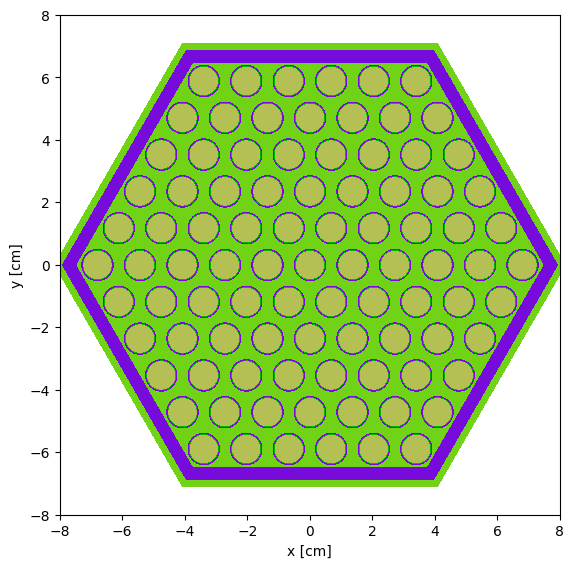

In [20]:
# Plotting 
geometry.plot(origin=(0.,0.,0.), pixels=(500, 500), width=(16,16), color_by='material')

In [21]:
diam_core=300

# BREAK

### Lattice for middle fuel assemblies

# Unbreak


<Axes: xlabel='x [cm]', ylabel='z [cm]'>

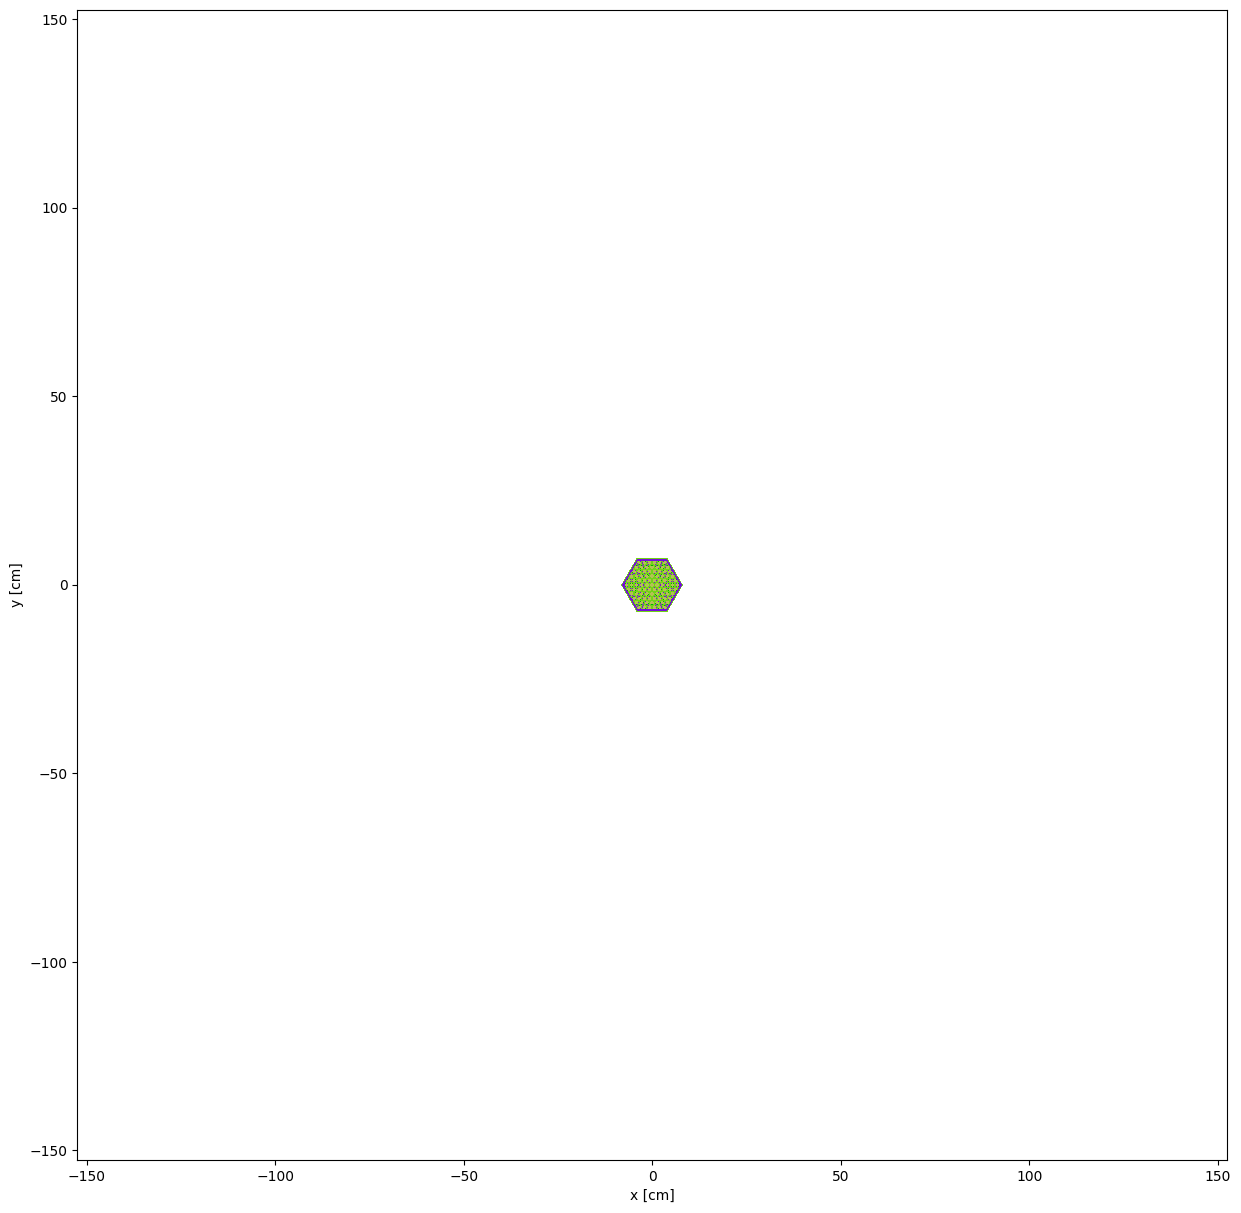

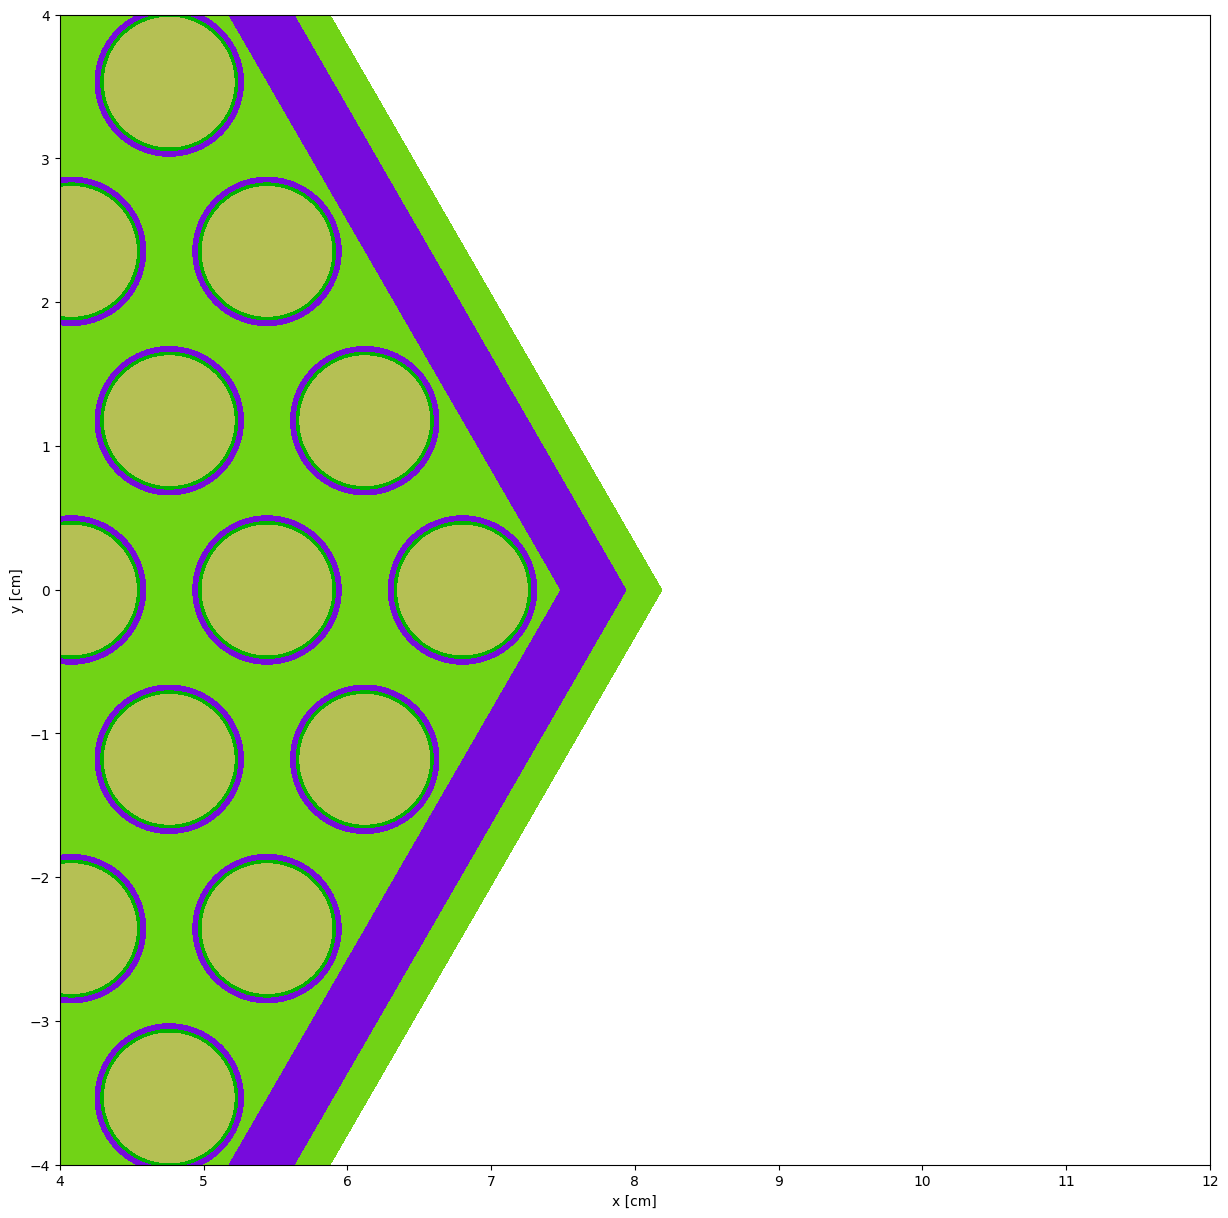

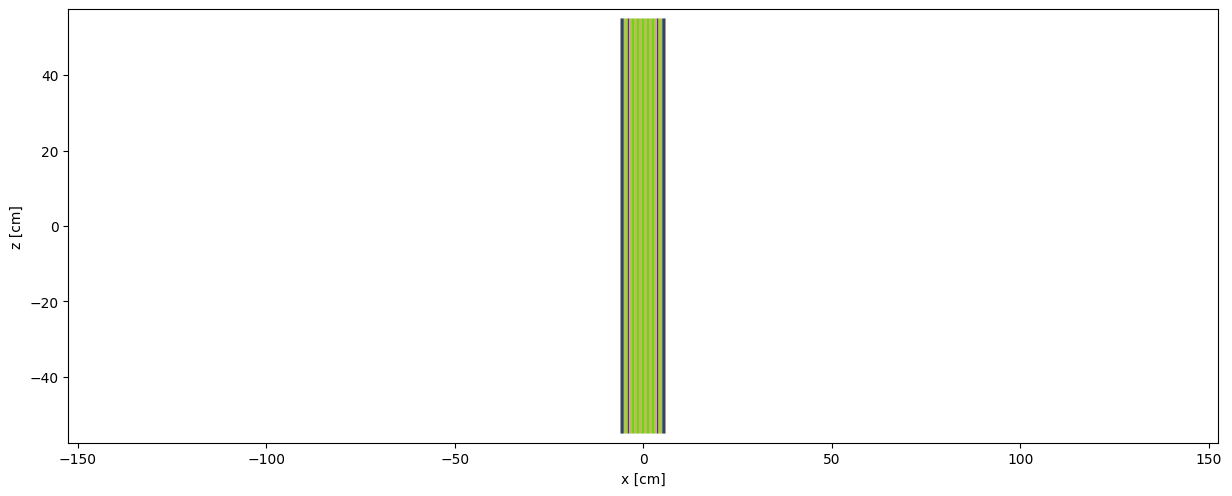

In [22]:
#Plotting
COLOR_BY_OPTION = 'material' #choose either 'material' or 'cell'
geometry.plot(origin=(0.,0.,0.), pixels=(1150,1150), width=(diam_core+5,diam_core+5), color_by="material")
geometry.plot(origin=(8.,0.,0.), pixels=(1150,1150), width=(8.,8.), color_by=COLOR_BY_OPTION) #zoom on gap betw. assemblies
geometry.plot(origin=(0.,edge_fuel_ass_in/2,0.), pixels=(1150,1150), width=(diam_core+5.,height_core+5), color_by=COLOR_BY_OPTION, basis='xz') #zx view, cut through y=edge_fuel_ass_in/2

## Simulation parameters

In [23]:
'''
#Creating box approx. containing core
lower_left = [-diam_core/15, -diam_core/15, -height_core/2] # to wit: z_height=100
upper_right = [diam_core/15, diam_core/15, height_core/2]
'''

# Convert mm → cm once, then use consistently
core_radius_cm   = 5   
half_height_cm   = height_core / 2.0        # if height_core already in cm

lower_left  = [-core_radius_cm, -core_radius_cm, -half_height_cm]
upper_right = [ core_radius_cm,  core_radius_cm,  half_height_cm]

#Uniform distribution of coordinates in a rectangular cuboid (should by cylinder...).
uniform_dist = openmc.stats.Box(lower_left, upper_right)

#Initial exernal source distribution
src = openmc.IndependentSource(
    space=uniform_dist, 
    constraints={'fissionable': True}) #limits which sampled source sites are actually used for transport (only fissionable material)

settings = openmc.Settings()
settings.temperature = {'method': 'interpolation'}

settings.source = src

#Run strategy (NB: here only one fission generation per batch  (std. setting))
settings.batches = 500
#Inactive Batches: batches run before tallies are 'turned on'. 
settings.inactive = 200
settings.particles = 1000

settings.export_to_xml()

## Tallies

In [24]:
import numpy as np

# Energy Mesh for the Spectrum:
e_min, e_max = 1.0e-2, 1.0e8
#Experiment with different binning
e_groups_50 = 50000
e_groups_10 = 10000
e_groups_5 = 5000
e_groups_1 = 1000
energies_50 = np.logspace(np.log10(e_min), np.log10(e_max), e_groups_50+1)
energies_10 = np.logspace(np.log10(e_min), np.log10(e_max), e_groups_10+1)
energies_5 = np.logspace(np.log10(e_min), np.log10(e_max), e_groups_5+1)
energies_1 = np.logspace(np.log10(e_min), np.log10(e_max), e_groups_1+1)

# Filters: Particles
neutron_filter = openmc.ParticleFilter("neutron") # since photon transport is enabled it will be counted in the neutron flux if I do not put a particle filter

# Filter: Energies
energy_filter_50 = openmc.EnergyFilter(energies_50)
energy_filter_10 = openmc.EnergyFilter(energies_10)
energy_filter_5 = openmc.EnergyFilter(energies_5)
energy_filter_1 = openmc.EnergyFilter(energies_1)

# Tally definition
tally_50 = openmc.Tally(name='Spectrum')
tally_10 = openmc.Tally(name='Spectrum')
tally_5 = openmc.Tally(name='Spectrum')
tally_1 = openmc.Tally(name='Spectrum')

tally_50.filters = [energy_filter_50, neutron_filter]
tally_50.scores = ['flux']
tally_10.filters = [energy_filter_10, neutron_filter]
tally_10.scores = ['flux']
tally_5.filters = [energy_filter_5, neutron_filter]
tally_5.scores = ['flux']
tally_1.filters = [energy_filter_1, neutron_filter]
tally_1.scores = ['flux']

# Export to "tallies.xml"
tallies = openmc.Tallies([tally_50, tally_10, tally_5, tally_1])
tallies.export_to_xml()

## Run OpenMC

In [25]:
RUN_variable = True
if RUN_variable:
    openmc.run()


                                %%%%%%%%%%%%%%%
                           %%%%%%%%%%%%%%%%%%%%%%%%
                        %%%%%%%%%%%%%%%%%%%%%%%%%%%%%%
                      %%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%
                    %%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%
                   %%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%
                                    %%%%%%%%%%%%%%%%%%%%%%%%
                                     %%%%%%%%%%%%%%%%%%%%%%%%
                 ###############      %%%%%%%%%%%%%%%%%%%%%%%%
                ##################     %%%%%%%%%%%%%%%%%%%%%%%
                ###################     %%%%%%%%%%%%%%%%%%%%%%%
                ####################     %%%%%%%%%%%%%%%%%%%%%%
                #####################     %%%%%%%%%%%%%%%%%%%%%
                ######################     %%%%%%%%%%%%%%%%%%%%
                #######################     %%%%%%%%%%%%%%%%%%
                 #######################     %%%%%%%%%%%%%%%%%
                 #####################